In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('weatherAUS.csv')

# Remove a coluna Date
df = df.drop(['Date'], axis=1)

# Remove as linhas nulas da coluna de resultado esperado
df.dropna(subset=['RainTomorrow'], inplace=True)

# Separa as colunas categóricas e numéricas
categorical_cols = df.select_dtypes(include=['object']).columns
numeric_cols = df.select_dtypes(exclude=['object']).columns

# Aplica a mediana para preencher os valores NA das colunas numéricas
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Aplica a moda para preencer os valores NA das colunas categóricas
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# Transforma as categóricas binárias 'Yes' e 'No' em 0 e 1
le = LabelEncoder()
df['RainToday'] = le.fit_transform(df['RainToday'])
df['RainTomorrow'] = le.fit_transform(df['RainTomorrow'])

X = df.drop(['RainTomorrow'], axis=1)
y = df['RainTomorrow']

# Filtra as colunas categóricas para o get_dummies
cols_to_dummy = [col for col in categorical_cols if col not in ['RainToday', 'RainTomorrow']]

# Aplica o One-Hot Encoding nas categóricas que sobraram
X = pd.get_dummies(X, columns=cols_to_dummy, drop_first=True)

# Separação dos dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Salva os nomes das colunas
final_cols = X_train.columns

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(X_train, columns=final_cols)
X_test = pd.DataFrame(X_test, columns=final_cols)

print(f"X_train={X_train.shape}, y_train={y_train.shape}")
print(f"X_test={X_test.shape}, y_test={y_test.shape}")

X_train=(76000, 94), y_train=(76000,)
X_test=(19001, 94), y_test=(19001,)


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

def create_model(input_dim):
  model = Sequential()

  model.add(Input(shape=(input_dim,)))

  model.add(Dense(128, activation='relu'))
  model.add(Dropout(0.3))

  model.add(Dense(64, activation='relu'))
  model.add(Dropout(0.2))

  model.add(Dense(32, activation='relu'))
  model.add(Dropout(0.2))

  model.add(Dense(1, activation='sigmoid'))

  model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
  )

  return model

model = create_model(X_train.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,529 (88.00 KB)

 Trainable params: 22,529 (88.00 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Class weights para lidar com desbalanceamento
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.6491731583982506), np.int64(1): np.float64(2.1759047182775997)}


In [4]:
from sklearn.model_selection import StratifiedKFold

N = 3
skf = StratifiedKFold(n_splits=N, shuffle=True, random_state=42)

fold_histories = []
fold_metrics_val = []

X_array = X_train.values
y_array = y_train.values

for fold, (train_index, val_index) in enumerate(skf.split(X_array, y_array), 1):
    print(f"\n{'='*30}")
    print(f"Fold {fold}/{N}")
    print(f"{'='*30}")

    X_fold_train, X_fold_val = X_array[train_index], X_array[val_index]
    y_fold_train, y_fold_val = y_array[train_index], y_array[val_index]

    model = create_model(X_fold_train.shape[1])

    history = model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=30,
        batch_size=128,
        class_weight=class_weight_dict,
        verbose=1
    )

    fold_histories.append(history.history)
    fold_metrics_val.append(max(history.history['val_accuracy']))
    print(f"Melhor val_accuracy: {fold_metrics_val[-1]:.4f}")

print(f"\n{'='*30}")
print(f"Val Accuracy média: {np.mean(fold_metrics_val):.4f} ± {np.std(fold_metrics_val):.4f}")
print(f"{'='*30}")


Fold 1/3
Epoch 1/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7289 - loss: 0.5336 - val_accuracy: 0.7848 - val_loss: 0.4556
Epoch 2/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7744 - loss: 0.4790 - val_accuracy: 0.7796 - val_loss: 0.4636
Epoch 3/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7840 - loss: 0.4610 - val_accuracy: 0.7879 - val_loss: 0.4410
Epoch 4/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7890 - loss: 0.4518 - val_accuracy: 0.7982 - val_loss: 0.4377
Epoch 5/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7939 - loss: 0.4457 - val_accuracy: 0.8000 - val_loss: 0.4291
Epoch 6/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7950 - loss: 0.4395 - val_accuracy: 0.7922 - val_loss: 0.4365
Epoch 7/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7979 - loss: 0.4339 - val_accuracy: 0.7996 - val_loss: 0.4312
Epoch 8/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7998 - loss: 0.4296 - val_ac

Epoch 1/30
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7399 - loss: 0.5248 - val_accuracy: 0.7901 - val_loss: 0.4565
Epoch 2/30
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7801 - loss: 0.4735 - val_accuracy: 0.8104 - val_loss: 0.4305
Epoch 3/30
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7905 - loss: 0.4579 - val_accuracy: 0.7970 - val_loss: 0.4444
Epoch 4/30
535/535 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7916 - loss: 0.4484 - val_accuracy: 0.8084 - val_loss: 0.4191
Epoch 5/30
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7945 - loss: 0.4441 - val_accuracy: 0.8003 - val_loss: 0.4346
Epoch 6/30
535/535 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7981 - loss: 0.4386 - val_accuracy: 0.7951 - val_loss: 0.4380
Epoch 7/30
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7990 - loss: 0.4344 - val_accuracy: 0.8079 - val_loss: 0.4098
Epoch 8/30
535/535 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8003 - loss: 0.4298 - val_accuracy: 0.

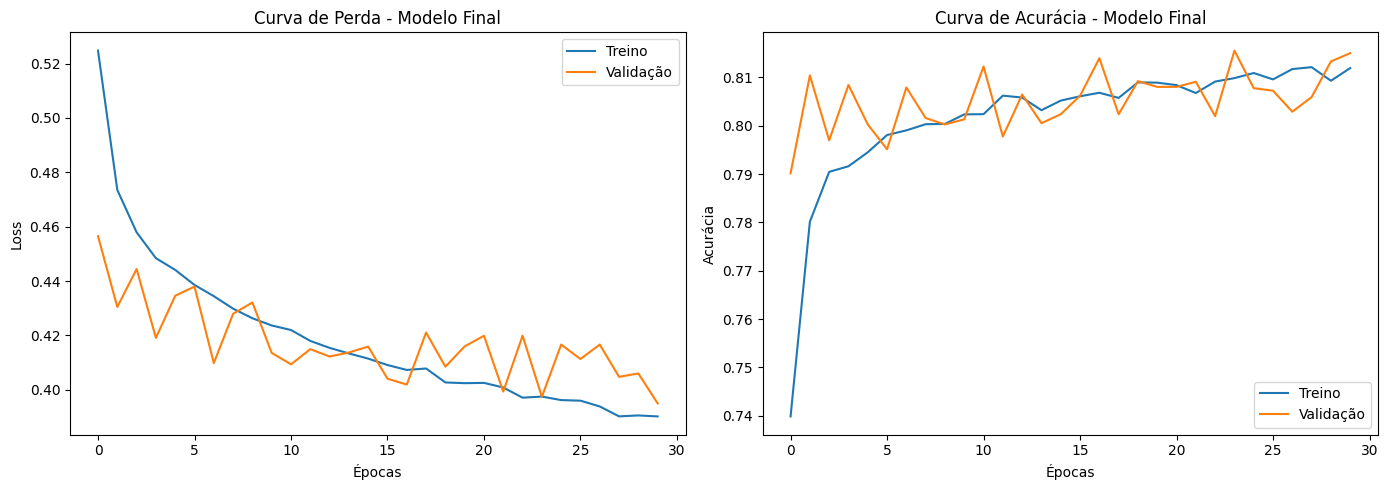

594/594 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step


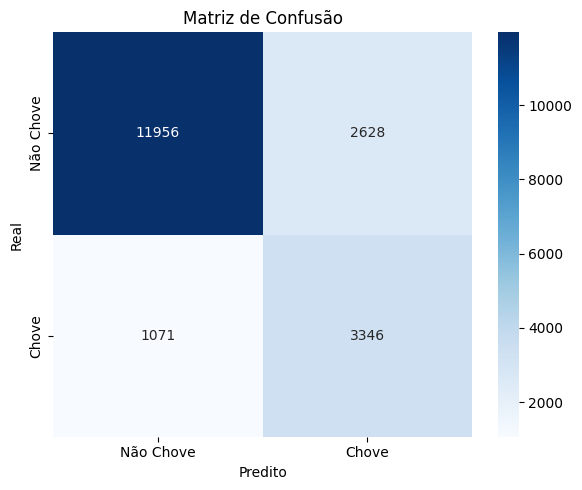


Métricas no Conjunto de Teste
Acurácia : 0.8053
Precisão : 0.5601
Recall   : 0.7575
F1-Score : 0.6440


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

final_model = create_model(X_train.shape[1])

final_history = final_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    class_weight=class_weight_dict,
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(final_history.history['loss'], label='Treino')
axes[0].plot(final_history.history['val_loss'], label='Validação')
axes[0].set_title('Curva de Perda - Modelo Final')
axes[0].set_xlabel('Épocas'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(final_history.history['accuracy'], label='Treino')
axes[1].plot(final_history.history['val_accuracy'], label='Validação')
axes[1].set_title('Curva de Acurácia - Modelo Final')
axes[1].set_xlabel('Épocas'); axes[1].set_ylabel('Acurácia')
axes[1].legend()
plt.tight_layout()
plt.show()

# Predições no teste
y_prob = final_model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Chove', 'Chove'],
            yticklabels=['Não Chove', 'Chove'])
plt.title('Matriz de Confusão')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
plt.show()

# Métricas
print("\nMétricas no Conjunto de Teste")
print(f"Acurácia : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão : {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")

In [6]:
import joblib, json

final_model.save('rain_model.keras')
joblib.dump(scaler, 'scaler.pkl')

with open('model_columns.json', 'w') as f:
    json.dump(list(final_cols), f)

print("Artefatos salvos!")

Artefatos salvos!
